Dataset loaded successfully!

========== FIRST 5 ROWS ==========
    Order_ID Customer_ID  Customer_Name  Order_Date    City Region  \
0  ORD101504    CUST2103  Sneha Agarwal  2025-03-03    Pune   West   
1  ORD100538    CUST1386   Aarav Sharma  2025-08-14  Jaipur  North   
2  ORD103551    CUST1398   Ishaan Kumar  2025-12-11    Pune   West   
3  ORD104945    CUST1141     Diya Gupta  2025-05-17  Jaipur  North   
4  ORD104817    CUST1266   Aditya Joshi  2025-07-07  Mumbai   West   

      Category        Product  Quantity  Unit_Price  Discount    Sales  \
0     Clothing        T-Shirt         2      763.94      0.00  1527.88   
1       Sports  Running Shoes         1     2734.44      0.05  2597.72   
2       Beauty      Face Wash         5      367.75      0.15  1562.94   
3       Beauty      Face Wash         1      422.87      0.15   359.44   
4  Electronics     Headphones         5     1862.40      0.20  7449.60   

    Profit      Payment_Mode Shipping_Mode  Customer_Rating  
0   400

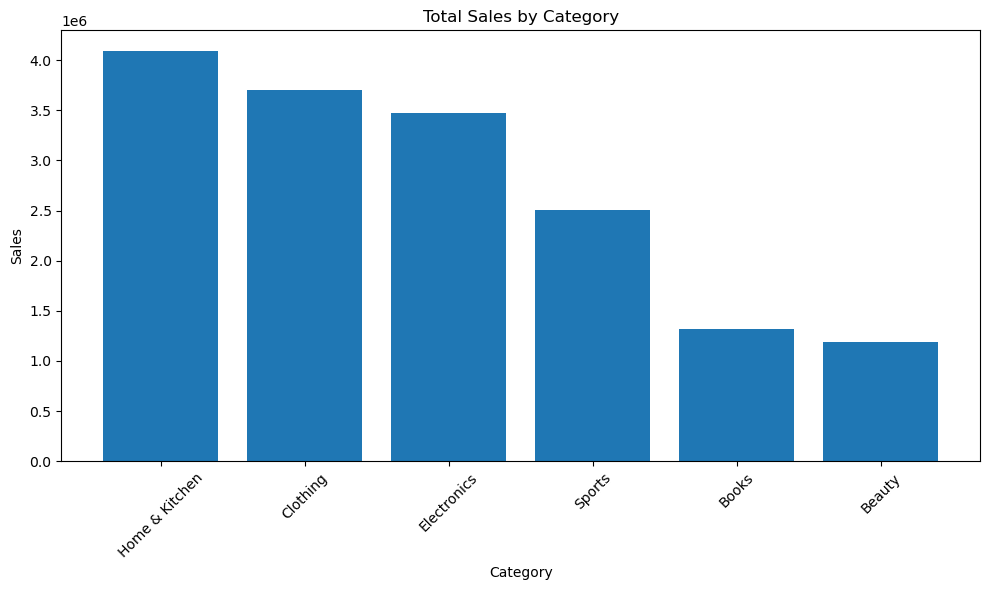

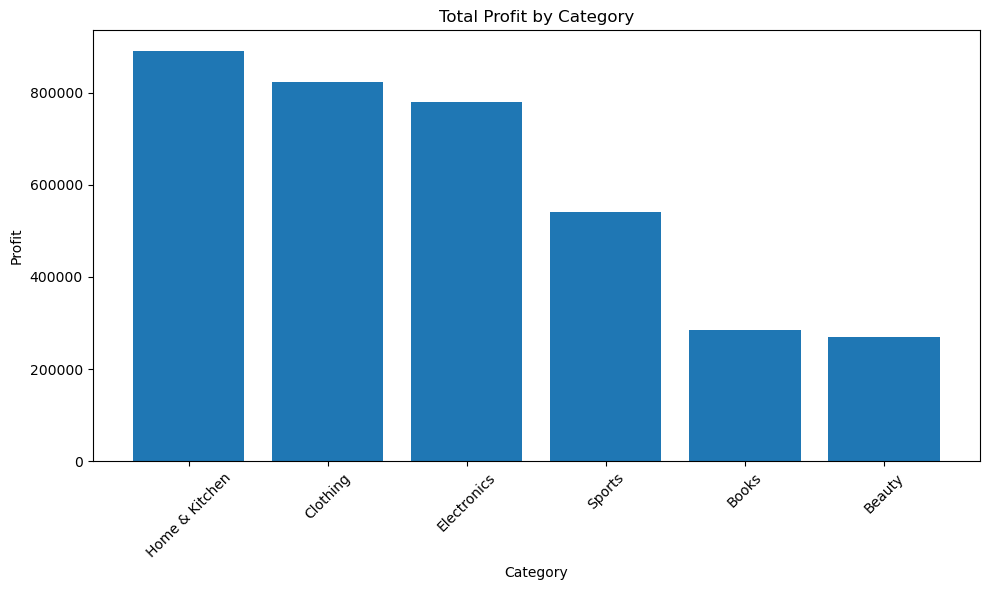

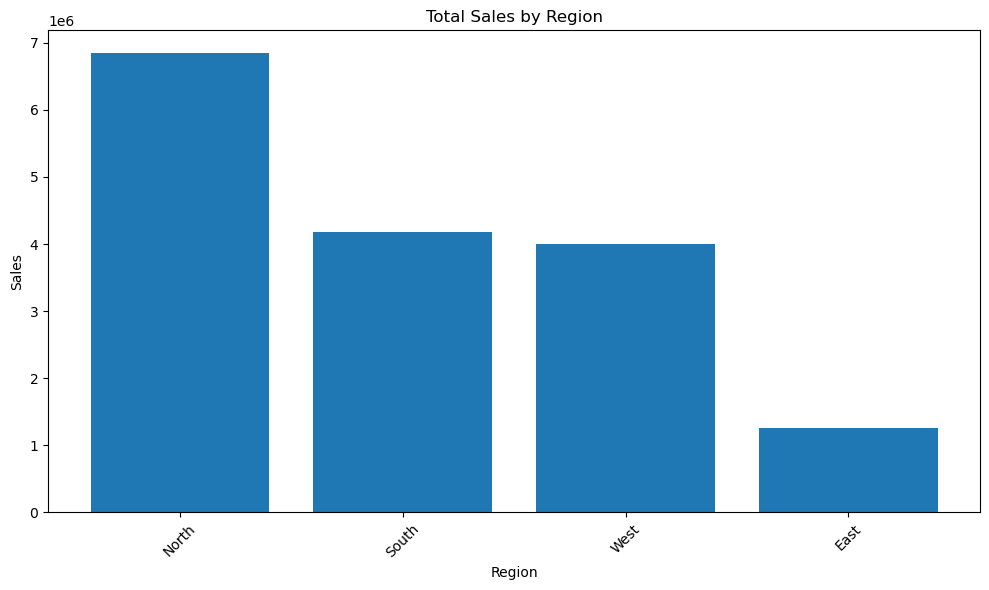

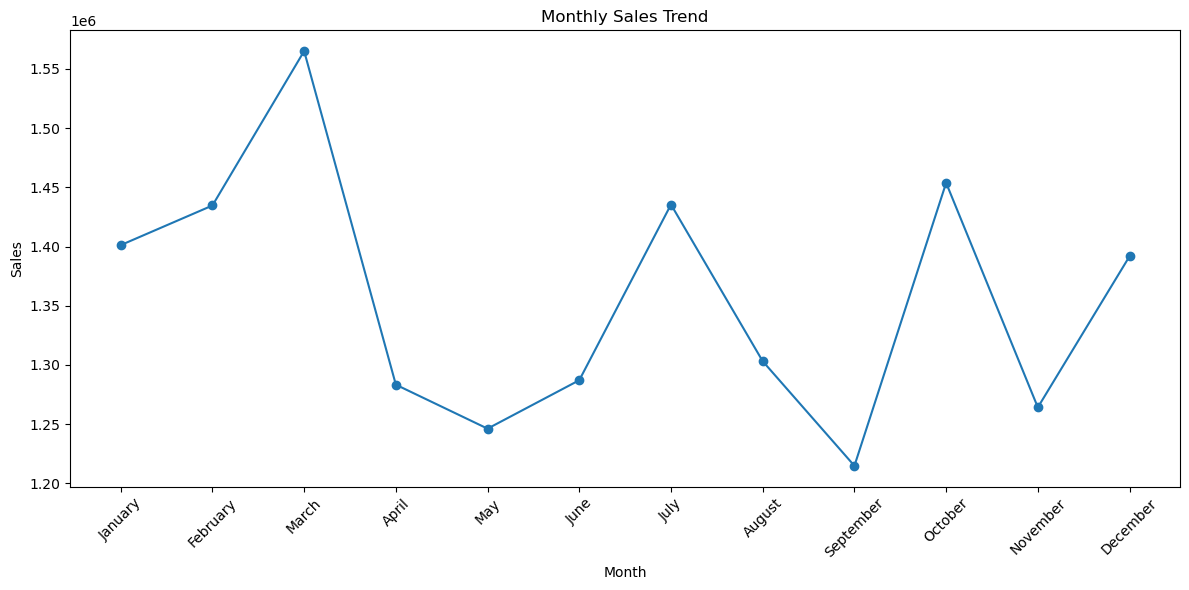

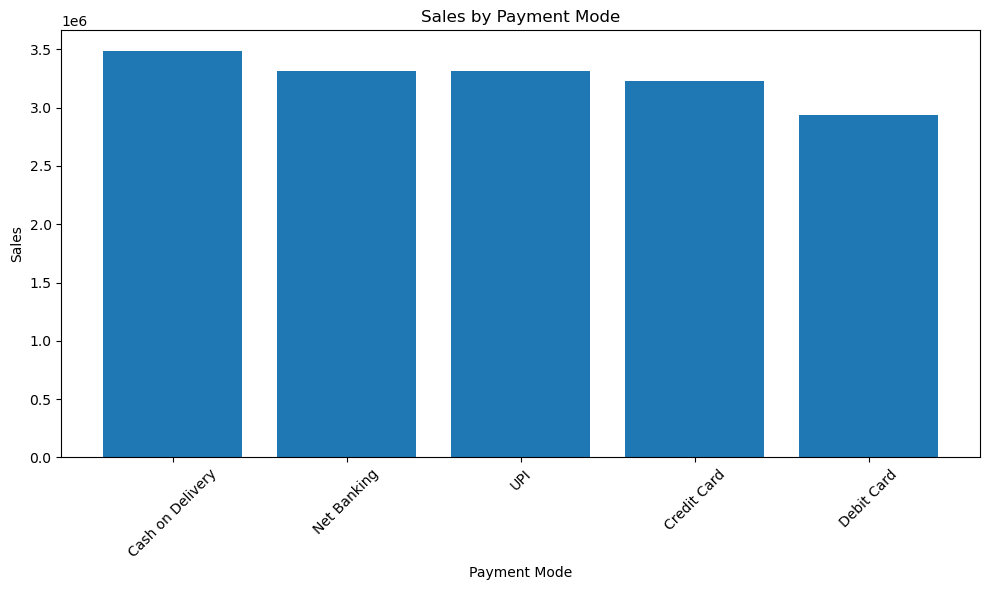

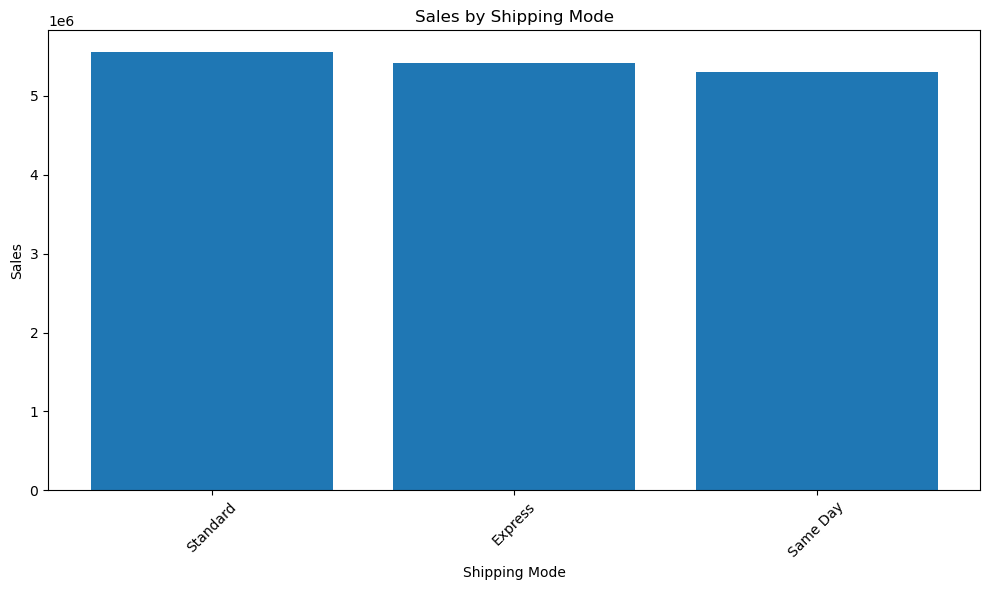

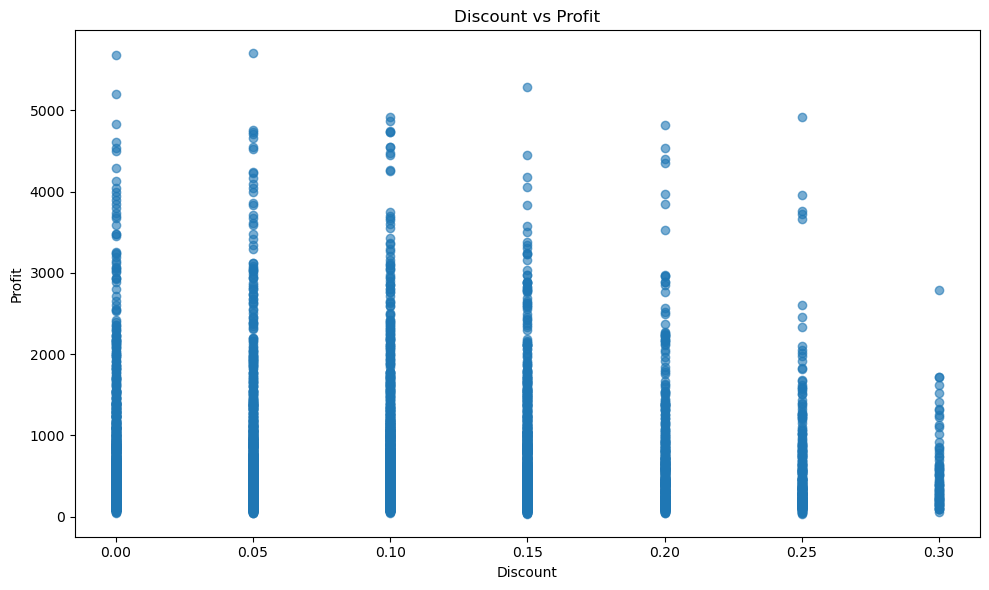

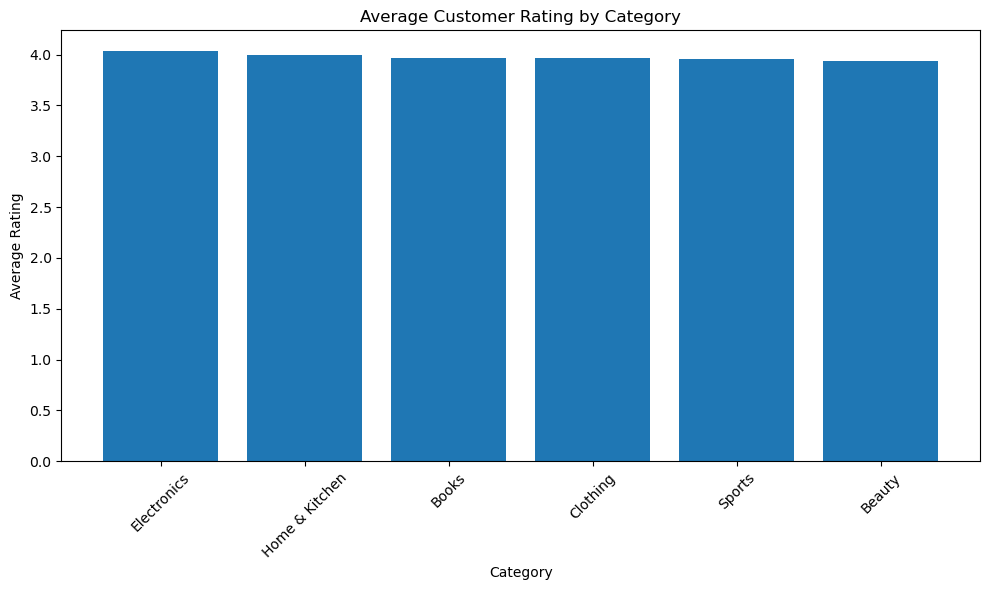


========== CORRELATION MATRIX ==========
                 Quantity  Unit_Price  Discount     Sales    Profit  \
Quantity         1.000000   -0.003897 -0.011661  0.675943  0.480121   
Unit_Price      -0.003897    1.000000  0.014170  0.593141  0.599712   
Discount        -0.011661    0.014170  1.000000 -0.073884 -0.085518   
Sales            0.675943    0.593141 -0.073884  1.000000  0.809488   
Profit           0.480121    0.599712 -0.085518  0.809488  1.000000   
Customer_Rating  0.023738    0.013217 -0.012662  0.023120  0.025304   

                 Customer_Rating  
Quantity                0.023738  
Unit_Price              0.013217  
Discount               -0.012662  
Sales                   0.023120  
Profit                  0.025304  
Customer_Rating         1.000000  


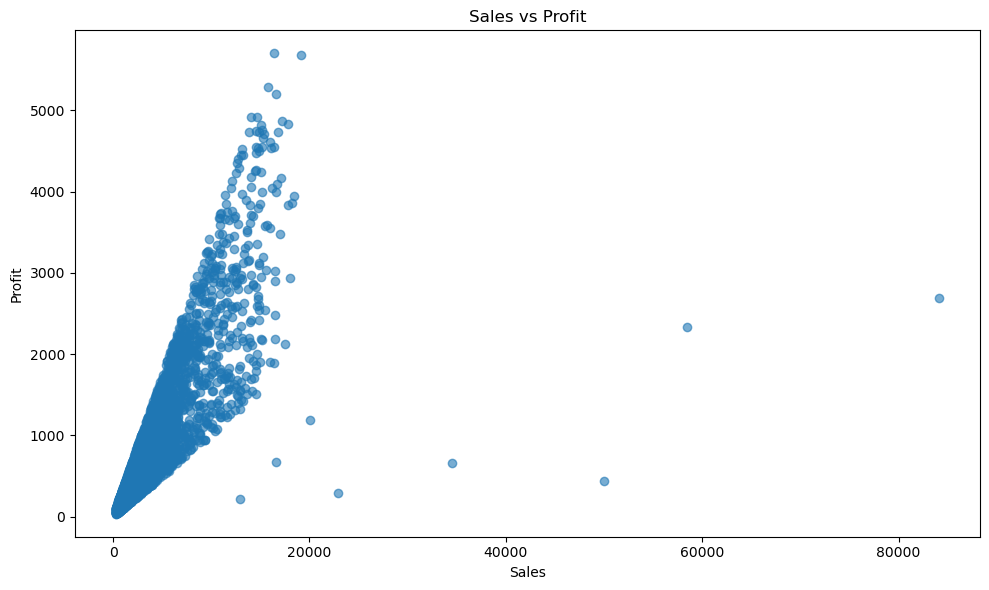



FINAL BUSINESS INSIGHTS

1. Highest Sales Category: Home & Kitchen
2. Highest Profit Category: Home & Kitchen
3. Highest Sales Region: North
4. Highest Profit Region: North
5. Most Used Payment Method: Cash on Delivery
6. Most Used Shipping Method: Express
7. Highest Rated Category: Electronics
8. Highest Discount: 0.3
9. Average Profit Margin: 22.5 %

Final cleaned dataset saved successfully!


In [1]:
# ============================================================

# E-COMMERCE SALES & CUSTOMER INSIGHTS

# Python | Pandas | NumPy | Matplotlib

# ============================================================

# ============================================================

# 1. IMPORT LIBRARIES

# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ============================================================

# 2. LOAD DATASET

# ============================================================

df = pd.read_csv(
r"C:\Users\anshi\Downloads\ecommerce_sales.csv"
)

print("Dataset loaded successfully!")

# ============================================================

# 3. UNDERSTAND THE DATASET

# ============================================================

print("\n========== FIRST 5 ROWS ==========")
print(df.head())

print("\n========== DATASET SHAPE ==========")
print(df.shape)

print("\n========== COLUMN NAMES ==========")
print(df.columns.tolist())

print("\n========== DATASET INFORMATION ==========")
df.info()

print("\n========== STATISTICAL SUMMARY ==========")
print(df.describe())

# ============================================================

# 4. CHECK MISSING VALUES

# ============================================================

print("\n========== MISSING VALUES BEFORE CLEANING ==========")
print(df.isnull().sum())

# ============================================================

# 5. CHECK DUPLICATES

# ============================================================

print("\n========== DUPLICATES ==========")
print("Duplicate rows:", df.duplicated().sum())

# ============================================================

# 6. REMOVE DUPLICATES

# ============================================================

df.drop_duplicates(inplace=True)

print("\nDuplicates after removal:")
print(df.duplicated().sum())

# ============================================================

# 7. FIX DATA TYPES

# ============================================================

df['Order_Date'] = pd.to_datetime(
df['Order_Date'],
format='mixed',
dayfirst=True
)

print("\nOrder_Date datatype:")
print(df['Order_Date'].dtype)

# ============================================================

# 8. HANDLE MISSING VALUES

# ============================================================

# Fill missing customer ratings with the mean rating

df.fillna(
{
'Customer_Rating': df['Customer_Rating'].mean()
},
inplace=True
)

# Remove any remaining rows containing missing values

df.dropna(inplace=True)

print("\n========== MISSING VALUES AFTER CLEANING ==========")
print(df.isnull().sum())

# ============================================================

# 9. CLEAN CATEGORICAL DATA

# ============================================================

print("\n========== CATEGORY VALUES BEFORE CLEANING ==========")
print(df['Category'].value_counts())

print("\n========== REGION VALUES ==========")
print(df['Region'].value_counts())

print("\n========== PAYMENT MODE VALUES ==========")
print(df['Payment_Mode'].value_counts())

print("\n========== SHIPPING MODE VALUES ==========")
print(df['Shipping_Mode'].value_counts())

# Remove unnecessary spaces

df['Category'] = df['Category'].str.strip()
df['Payment_Mode'] = df['Payment_Mode'].str.strip()
df['Region'] = df['Region'].str.strip()
df['Shipping_Mode'] = df['Shipping_Mode'].str.strip()

# Standardize category names

df['Category'] = df['Category'].str.title()

# Standardize payment mode names

df['Payment_Mode'] = df['Payment_Mode'].replace(
{
'COD': 'Cash on Delivery',
'upi': 'UPI',
'cash on delivery': 'Cash on Delivery',
'Credit card': 'Credit Card'
}
)

# ============================================================

# 10. CHECK NUMERICAL VALUES

# ============================================================

print("\n========== NUMERICAL SUMMARY ==========")

print(
df[
[
'Quantity',
'Unit_Price',
'Discount',
'Sales',
'Profit',
'Customer_Rating'
]
].describe()
)

# ============================================================

# 11. FEATURE ENGINEERING

# ============================================================

# Extract year, month and month name from Order_Date

df['Year'] = df['Order_Date'].dt.year

df['Month'] = df['Order_Date'].dt.month

df['Month_Name'] = df['Order_Date'].dt.month_name()

# Calculate profit margin

df['Profit_Margin'] = np.where(
df['Sales'] != 0,
(df['Profit'] / df['Sales']) * 100,
0
)

print("\n========== NEW FEATURES ==========")

print(
df[
[
'Order_Date',
'Year',
'Month',
'Month_Name',
'Profit_Margin'
]
].head()
)

# ============================================================

# 12. FINAL DATASET CHECK

# ============================================================

print("\n========== FINAL DATA VALIDATION ==========")

print("\nFinal shape:")
print(df.shape)

print("\nMissing values:")
print(df.isnull().sum())

print("\nDuplicate rows:")
print(df.duplicated().sum())

print("\nData types:")
print(df.dtypes)

# ============================================================

# 13. BASIC BUSINESS KPIs

# ============================================================

total_sales = df['Sales'].sum()

total_profit = df['Profit'].sum()

total_quantity = df['Quantity'].sum()

average_sales = df['Sales'].mean()

average_profit = df['Profit'].mean()

average_rating = df['Customer_Rating'].mean()

average_profit_margin = df['Profit_Margin'].mean()

print("\n========== BUSINESS KPIs ==========")

print("Total Sales:", round(total_sales, 2))

print("Total Profit:", round(total_profit, 2))

print("Total Quantity Sold:", total_quantity)

print("Average Sales per Record:", round(average_sales, 2))

print("Average Profit per Record:", round(average_profit, 2))

print("Average Customer Rating:", round(average_rating, 2))

print("Average Profit Margin:", round(average_profit_margin, 2), "%")

# ============================================================

# 14. CATEGORY ANALYSIS

# ============================================================

category_analysis = (
df.groupby('Category')
.agg(
Total_Sales=('Sales', 'sum'),
Total_Profit=('Profit', 'sum'),
Total_Quantity=('Quantity', 'sum'),
Average_Rating=('Customer_Rating', 'mean')
)
.sort_values(
'Total_Sales',
ascending=False
)
)

print("\n========== CATEGORY ANALYSIS ==========")
print(category_analysis)

# ============================================================

# 15. TOP CATEGORY

# ============================================================

top_category = category_analysis.index[0]

print("\nTop category by sales:", top_category)

# ============================================================

# 16. REGION ANALYSIS

# ============================================================

region_analysis = (
df.groupby('Region')
.agg(
Total_Sales=('Sales', 'sum'),
Total_Profit=('Profit', 'sum'),
Total_Quantity=('Quantity', 'sum')
)
.sort_values(
'Total_Sales',
ascending=False
)
)

print("\n========== REGION ANALYSIS ==========")
print(region_analysis)

# ============================================================

# 17. TOP REGION

# ============================================================

top_region = region_analysis.index[0]

print("\nTop region by sales:", top_region)

# ============================================================

# 18. PAYMENT MODE ANALYSIS

# ============================================================

payment_analysis = (
df.groupby('Payment_Mode')
.agg(
Total_Sales=('Sales', 'sum'),
Total_Orders=('Order_ID', 'count')
)
.sort_values(
'Total_Sales',
ascending=False
)
)

print("\n========== PAYMENT MODE ANALYSIS ==========")
print(payment_analysis)

# ============================================================

# 19. SHIPPING MODE ANALYSIS

# ============================================================

shipping_analysis = (
df.groupby('Shipping_Mode')
.agg(
Total_Sales=('Sales', 'sum'),
Total_Profit=('Profit', 'sum'),
Total_Orders=('Order_ID', 'count')
)
.sort_values(
'Total_Sales',
ascending=False
)
)

print("\n========== SHIPPING MODE ANALYSIS ==========")
print(shipping_analysis)

# ============================================================

# 20. CUSTOMER ANALYSIS

# ============================================================

customer_analysis = (
df.groupby('Customer_ID')
.agg(
Total_Sales=('Sales', 'sum'),
Total_Orders=('Order_ID', 'count'),
Total_Quantity=('Quantity', 'sum'),
Total_Profit=('Profit', 'sum')
)
.sort_values(
'Total_Sales',
ascending=False
)
)

print("\n========== TOP 10 CUSTOMERS ==========")

print(
customer_analysis.head(10)
)

# ============================================================

# 21. CUSTOMER RATING ANALYSIS

# ============================================================

rating_analysis = (
df.groupby('Category')['Customer_Rating']
.mean()
.sort_values(
ascending=False
)
)

print("\n========== AVERAGE RATING BY CATEGORY ==========")

print(rating_analysis)

# ============================================================

# 22. DISCOUNT ANALYSIS

# ============================================================

discount_analysis = (
df.groupby('Discount')
.agg(
Total_Sales=('Sales', 'sum'),
Total_Profit=('Profit', 'sum')
)
.sort_index()
)

print("\n========== DISCOUNT ANALYSIS ==========")

print(discount_analysis)

# ============================================================

# 23. MONTHLY SALES ANALYSIS

# ============================================================

monthly_sales = (
df.groupby(
['Year', 'Month', 'Month_Name']
)['Sales']
.sum()
.reset_index()
.sort_values(
['Year', 'Month']
)
)

print("\n========== MONTHLY SALES ==========")

print(monthly_sales)

# ============================================================

# 24. MONTHLY PROFIT ANALYSIS

# ============================================================

monthly_profit = (
df.groupby(
['Year', 'Month', 'Month_Name']
)['Profit']
.sum()
.reset_index()
.sort_values(
['Year', 'Month']
)
)

print("\n========== MONTHLY PROFIT ==========")

print(monthly_profit)


# ============================================================

# 25. VISUALIZATION 1

# SALES BY CATEGORY

# ============================================================

plt.figure(figsize=(10, 6))

plt.bar(
category_analysis.index,
category_analysis['Total_Sales']
)

plt.title('Total Sales by Category')

plt.xlabel('Category')

plt.ylabel('Sales')

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()

# ============================================================

# 26. VISUALIZATION 2

# PROFIT BY CATEGORY

# ============================================================

plt.figure(figsize=(10, 6))

plt.bar(
category_analysis.index,
category_analysis['Total_Profit']
)

plt.title('Total Profit by Category')

plt.xlabel('Category')

plt.ylabel('Profit')

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()

# ============================================================

# 27. VISUALIZATION 3

# SALES BY REGION

# ============================================================

plt.figure(figsize=(10, 6))

plt.bar(
region_analysis.index,
region_analysis['Total_Sales']
)

plt.title('Total Sales by Region')

plt.xlabel('Region')

plt.ylabel('Sales')

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()

# ============================================================

# 28. VISUALIZATION 4

# MONTHLY SALES TREND

# ============================================================

plt.figure(figsize=(12, 6))

plt.plot(
monthly_sales['Month_Name'],
monthly_sales['Sales'],
marker='o'
)

plt.title('Monthly Sales Trend')

plt.xlabel('Month')

plt.ylabel('Sales')

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()

# ============================================================

# 29. VISUALIZATION 5

# PAYMENT MODE SALES

# ============================================================

plt.figure(figsize=(10, 6))

plt.bar(
payment_analysis.index,
payment_analysis['Total_Sales']
)

plt.title('Sales by Payment Mode')

plt.xlabel('Payment Mode')

plt.ylabel('Sales')

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()

# ============================================================

# 30. VISUALIZATION 6

# SHIPPING MODE SALES

# ============================================================

plt.figure(figsize=(10, 6))

plt.bar(
shipping_analysis.index,
shipping_analysis['Total_Sales']
)

plt.title('Sales by Shipping Mode')

plt.xlabel('Shipping Mode')

plt.ylabel('Sales')

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()

# ============================================================

# 31. VISUALIZATION 7

# DISCOUNT VS PROFIT

# ============================================================

plt.figure(figsize=(10, 6))

plt.scatter(
df['Discount'],
df['Profit'],
alpha=0.6
)

plt.title('Discount vs Profit')

plt.xlabel('Discount')

plt.ylabel('Profit')

plt.tight_layout()

plt.show()

# ============================================================

# 32. VISUALIZATION 8

# CUSTOMER RATING BY CATEGORY

# ============================================================

plt.figure(figsize=(10, 6))

plt.bar(
rating_analysis.index,
rating_analysis.values
)

plt.title('Average Customer Rating by Category')

plt.xlabel('Category')

plt.ylabel('Average Rating')

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()

# ============================================================

# 33. CORRELATION ANALYSIS

# ============================================================

numeric_columns = [
'Quantity',
'Unit_Price',
'Discount',
'Sales',
'Profit',
'Customer_Rating'
]

correlation = df[numeric_columns].corr()

print("\n========== CORRELATION MATRIX ==========")

print(correlation)

# ============================================================

# 34. SALES VS PROFIT

# ============================================================

plt.figure(figsize=(10, 6))

plt.scatter(
df['Sales'],
df['Profit'],
alpha=0.6
)

plt.title('Sales vs Profit')

plt.xlabel('Sales')

plt.ylabel('Profit')

plt.tight_layout()

plt.show()

# ============================================================

# 35. FINAL INSIGHTS

# ============================================================

print("\n")
print("=" * 60)
print("FINAL BUSINESS INSIGHTS")
print("=" * 60)

# Top category

print(
"\n1. Highest Sales Category:",
category_analysis['Total_Sales'].idxmax()
)

# Highest profit category

print(
"2. Highest Profit Category:",
category_analysis['Total_Profit'].idxmax()
)

# Highest sales region

print(
"3. Highest Sales Region:",
region_analysis['Total_Sales'].idxmax()
)

# Highest profit region

print(
"4. Highest Profit Region:",
region_analysis['Total_Profit'].idxmax()
)

# Most used payment method

print(
"5. Most Used Payment Method:",
df['Payment_Mode'].value_counts().idxmax()
)

# Most used shipping method

print(
"6. Most Used Shipping Method:",
df['Shipping_Mode'].value_counts().idxmax()
)

# Highest rated category

print(
"7. Highest Rated Category:",
rating_analysis.idxmax()
)

# Highest discount

print(
"8. Highest Discount:",
df['Discount'].max()
)

# Average profit margin

print(
"9. Average Profit Margin:",
round(
df['Profit_Margin'].mean(),
2
),
"%"
)

# ============================================================

# 36. SAVE FINAL CLEANED DATASET

# ============================================================

df.to_csv(
r"C:\Users\anshi\Downloads\Cleaned_Ecommerce_data.csv",
index=False
)

print("\nFinal cleaned dataset saved successfully!")


